# Step1: import pandas, load csv file

In [1]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\ACS\Downloads\archive (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step2: Understand the dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# step3: check totalcharges

In [4]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
20.45     5
20.3      5
19.4      4
75.3      4
44.4      4
19.3      4
19.85     4
20.5      4
70.6      4
Name: count, dtype: int64

In [5]:
df[df["TotalCharges"].str.strip() == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# step4: check missing vlaues

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, dtype: int64

# Step 5 — Check for blank spaces in TotalCharges

In [8]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Step 6 — Handle the missing TotalCharges

In [12]:
df = df.dropna(subset=["TotalCharges"])

## Step 7 — Remove the rows where TotalCharges is missing

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(0)

## Step 8 — Check the dataset size

In [14]:
df.shape

(7032, 21)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## Step 10 — Check for duplicate customers

In [16]:
df["customerID"].duplicated().sum()

np.int64(0)

In [17]:
df.duplicated().sum()

np.int64(0)

## Step 11 — Create TenureGroup

In [18]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [19]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "61-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [20]:
df.copy()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,13-24 months
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,61-72 months
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0-12 months
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,0-12 months


In [21]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "61-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [22]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,0-12 months
1,34,25-36 months
2,2,0-12 months
3,45,37-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-36 months
9,62,61-72 months


## Step 12 — Create AvgMonthlySpend

In [23]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, pd.NA)

## Step 13 — Check the new columns

In [24]:
df[["tenure", "TotalCharges", "AvgMonthlySpend"]].head(10)

,tenure,TotalCharges,AvgMonthlySpend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000
5,8,820.50,102.562500
6,22,1949.40,88.609091
7,10,301.90,30.190000
8,28,3046.05,108.787500
9,62,3487.95,56.257258


## Step 14 — Find the Yes/No columns

In [25]:
yes_no_columns = []

for column in df.columns:
    if set(df[column].dropna().unique()).issubset({"Yes", "No"}):
        yes_no_columns.append(column)

yes_no_columns

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

## Step 15 — Convert Yes/No → 1/0

In [26]:
df[yes_no_columns] = df[yes_no_columns].replace({
    "Yes": 1,
    "No": 0
})

C:\Users\ACS\AppData\Local\Temp\ipykernel_14500\1139817665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_columns] = df[yes_no_columns].replace({


In [27]:
df[yes_no_columns].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


## Step 16 — Find categorical columns

In [28]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['customerID', 'gender', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')

In [29]:
categorial_columns = categorical_columns.drop("customerID")

## Step 17 — One-hot encode the categorical columns

In [30]:
df_encoded = pd.get_dummies(df, columns=categorical_columns,drop_first= True,dtype=int)

In [31]:
df_encoded.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,0-12 months,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,25-36 months,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,0-12 months,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,37-48 months,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,0-12 months,...,0,0,0,0,0,0,0,0,1,0


In [32]:
df_encoded.shape

(7032, 7064)

In [33]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months,29.850000
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,No,No,One year,0,Mailed check,56.95,1889.50,0,25-36 months,55.573529
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 months,54.075000
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,37-48 months,40.905556
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 months,75.825000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,One year,1,Mailed check,84.80,1990.50,0,13-24 months,82.937500
7039,2234-XADUH,Female,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,0,61-72 months,102.262500
7040,4801-JZAZL,Female,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,Month-to-month,1,Electronic check,29.60,346.45,0,0-12 months,31.495455
7041,8361-LTMKD,Male,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,Month-to-month,1,Mailed check,74.40,306.60,1,0-12 months,76.650000


In [34]:
df_encoded

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,0-12 months,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,25-36 months,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,0-12 months,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,37-48 months,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,0-12 months,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,84.80,1990.50,0,13-24 months,...,1,0,1,0,1,1,0,0,0,1
7039,0,1,1,72,1,1,103.20,7362.90,0,61-72 months,...,0,0,1,0,1,1,0,1,0,0
7040,0,1,1,11,0,1,29.60,346.45,0,0-12 months,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,0,4,1,1,74.40,306.60,1,0-12 months,...,0,0,0,0,0,0,0,0,0,1


In [35]:
df_encoded.dtypes.value_counts()

int64       7060
float64        3
category       1
Name: count, dtype: int64

## step 18: churn distribution

In [36]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## step 19: data visulaization

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

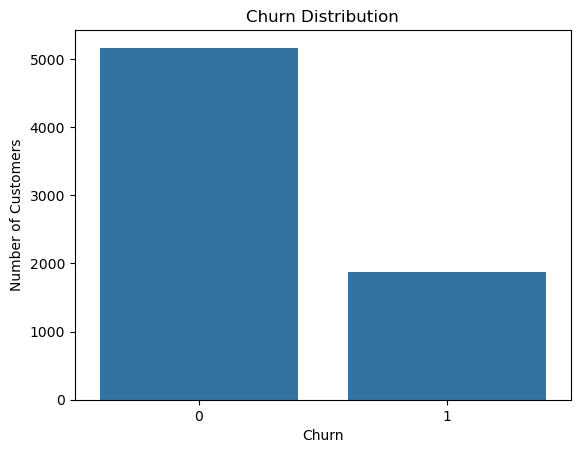

In [38]:
sns.countplot(x="Churn", data= df)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## step20: Contract vs Churn

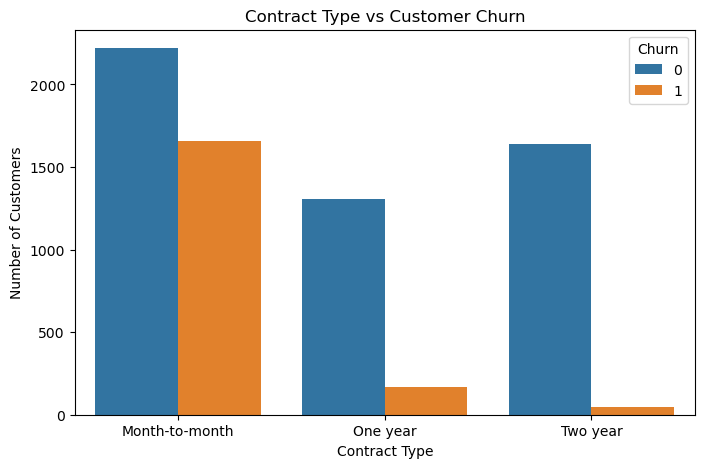

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

## Step 21 — Get the actual numbers

In [40]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## step22: correlation heatmap

In [41]:
df[["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "Churn"]].corr()["Churn"]

tenure            -0.354049
MonthlyCharges     0.192858
TotalCharges      -0.199484
AvgMonthlySpend    0.192033
Churn              1.000000
Name: Churn, dtype: float64

In [42]:
print("Notebook is working")

Notebook is working


In [44]:
heatmap_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "Churn"
]

correlation = df[heatmap_columns].corr()

correlation

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,Churn
tenure,1.000000,0.246862,0.825880,0.246198,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.996237,0.192858
TotalCharges,0.825880,0.651065,1.000000,0.650915,-0.199484
AvgMonthlySpend,0.246198,0.996237,0.650915,1.000000,0.192033
Churn,-0.354049,0.192858,-0.199484,0.192033,1.000000


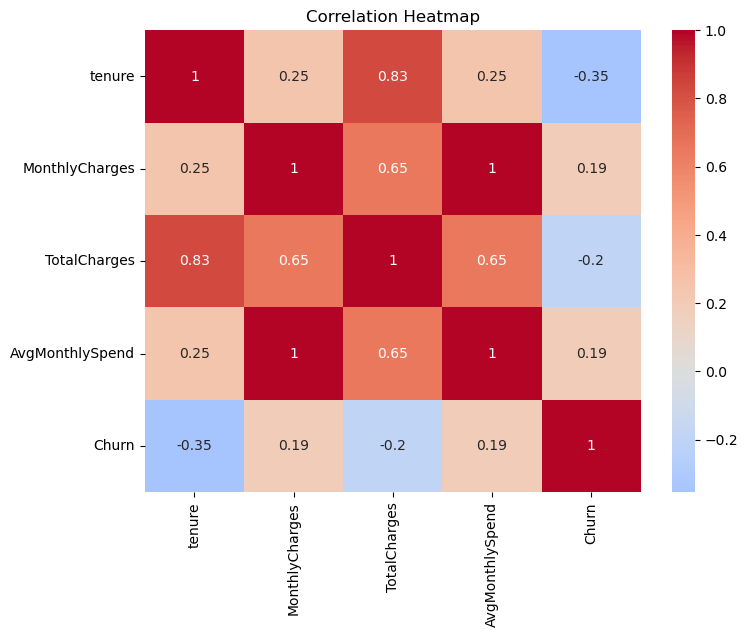

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()


## step23: Monthly Charges vs Churn

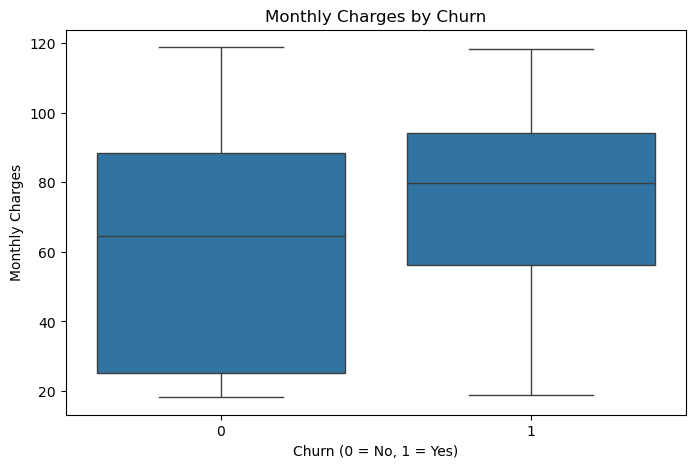

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")

plt.show()

## Step 24 — Let's get the actual numbers for our insights

In [47]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
0,5163,61.307408,64.45,18.25,118.75
1,1869,74.441332,79.65,18.85,118.35


In [48]:
df["Churn"].mean() * 100

np.float64(26.578498293515356)

## Step 25 — Save the cleaned dataset

In [49]:
import os

os.makedirs("output", exist_ok=True)

df.to_csv("output/customer_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## step26: verify the file

In [50]:
import os

print(os.path.exists("output/customer_churn_cleaned.csv"))

True


In [51]:
df.shape

(7032, 23)

In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months,29.850000
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,No,No,One year,0,Mailed check,56.95,1889.50,0,25-36 months,55.573529
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 months,54.075000
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,37-48 months,40.905556
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 months,75.825000


In [53]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [54]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
0,5163,61.307408,64.45,18.25,118.75
1,1869,74.441332,79.65,18.85,118.35


In [55]:
contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


### Top 5 Insights

1. The dataset contains 7,032 customers after removing records with invalid/missing TotalCharges values. Among them, 1,869 customers churned and 5,163 customers stayed, giving an overall churn rate of approximately 26.57%.

2. Customers who churned had higher monthly charges on average (74.44) compared with customers who stayed (61.31).

3. Monthly charges also had a higher median among churned customers (79.65) than among customers who stayed (64.45).

4. Month-to-month contract customers had the highest observed churn percentage at 42.71%, compared with 11.28% for one-year contracts and 2.85% for two-year contracts.

5. The analysis shows an association between contract type and churn in this dataset: longer-term contract groups had lower observed churn percentages than month-to-month customers. This is an observed relationship and does not by itself establish causation.